# SUPPORT VECTOR MACHINE

# Task 1: Exploratory Data Analysis (EDA)

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,accuracy_score,classification_report
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,OrdinalEncoder,OneHotEncoder 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [27]:
data = pd.read_csv(r"C:\Users\sangm\Documents\mushroom.csv")
data.head(3)

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884


In [28]:
data1 = data.drop(columns='Unnamed: 0')
data1

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,tapering,...,partial,orange,one,flaring,purple,abundant,leaves,poisonous,5.877891,17.464145
1996,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,tapering,...,partial,white,one,zone,yellow,numerous,waste,poisonous,6.500840,13.501957
1997,convex,grooves,green,yes,fishy,notched,close,narrow,pink,tapering,...,partial,brown,two,evanescent,yellow,abundant,woods,poisonous,13.558064,11.270020
1998,bell,smooth,white,no,pungent,free,close,narrow,orange,enlarging,...,universal,yellow,one,cobwebby,brown,solitary,woods,poisonous,11.092703,8.423199


In [30]:
data1.isnull().sum()

cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [31]:
data1.describe()

,stalk_height,cap_diameter
count,2000.000000,2000.000000
mean,8.449118,12.314345
std,3.697217,7.048845
min,2.000000,1.000000
25%,5.291009,5.723521
50%,8.318596,12.124902
75%,11.781272,18.698605
max,15.095066,25.000054


# Data Visualization

<Axes: ylabel='Count'>

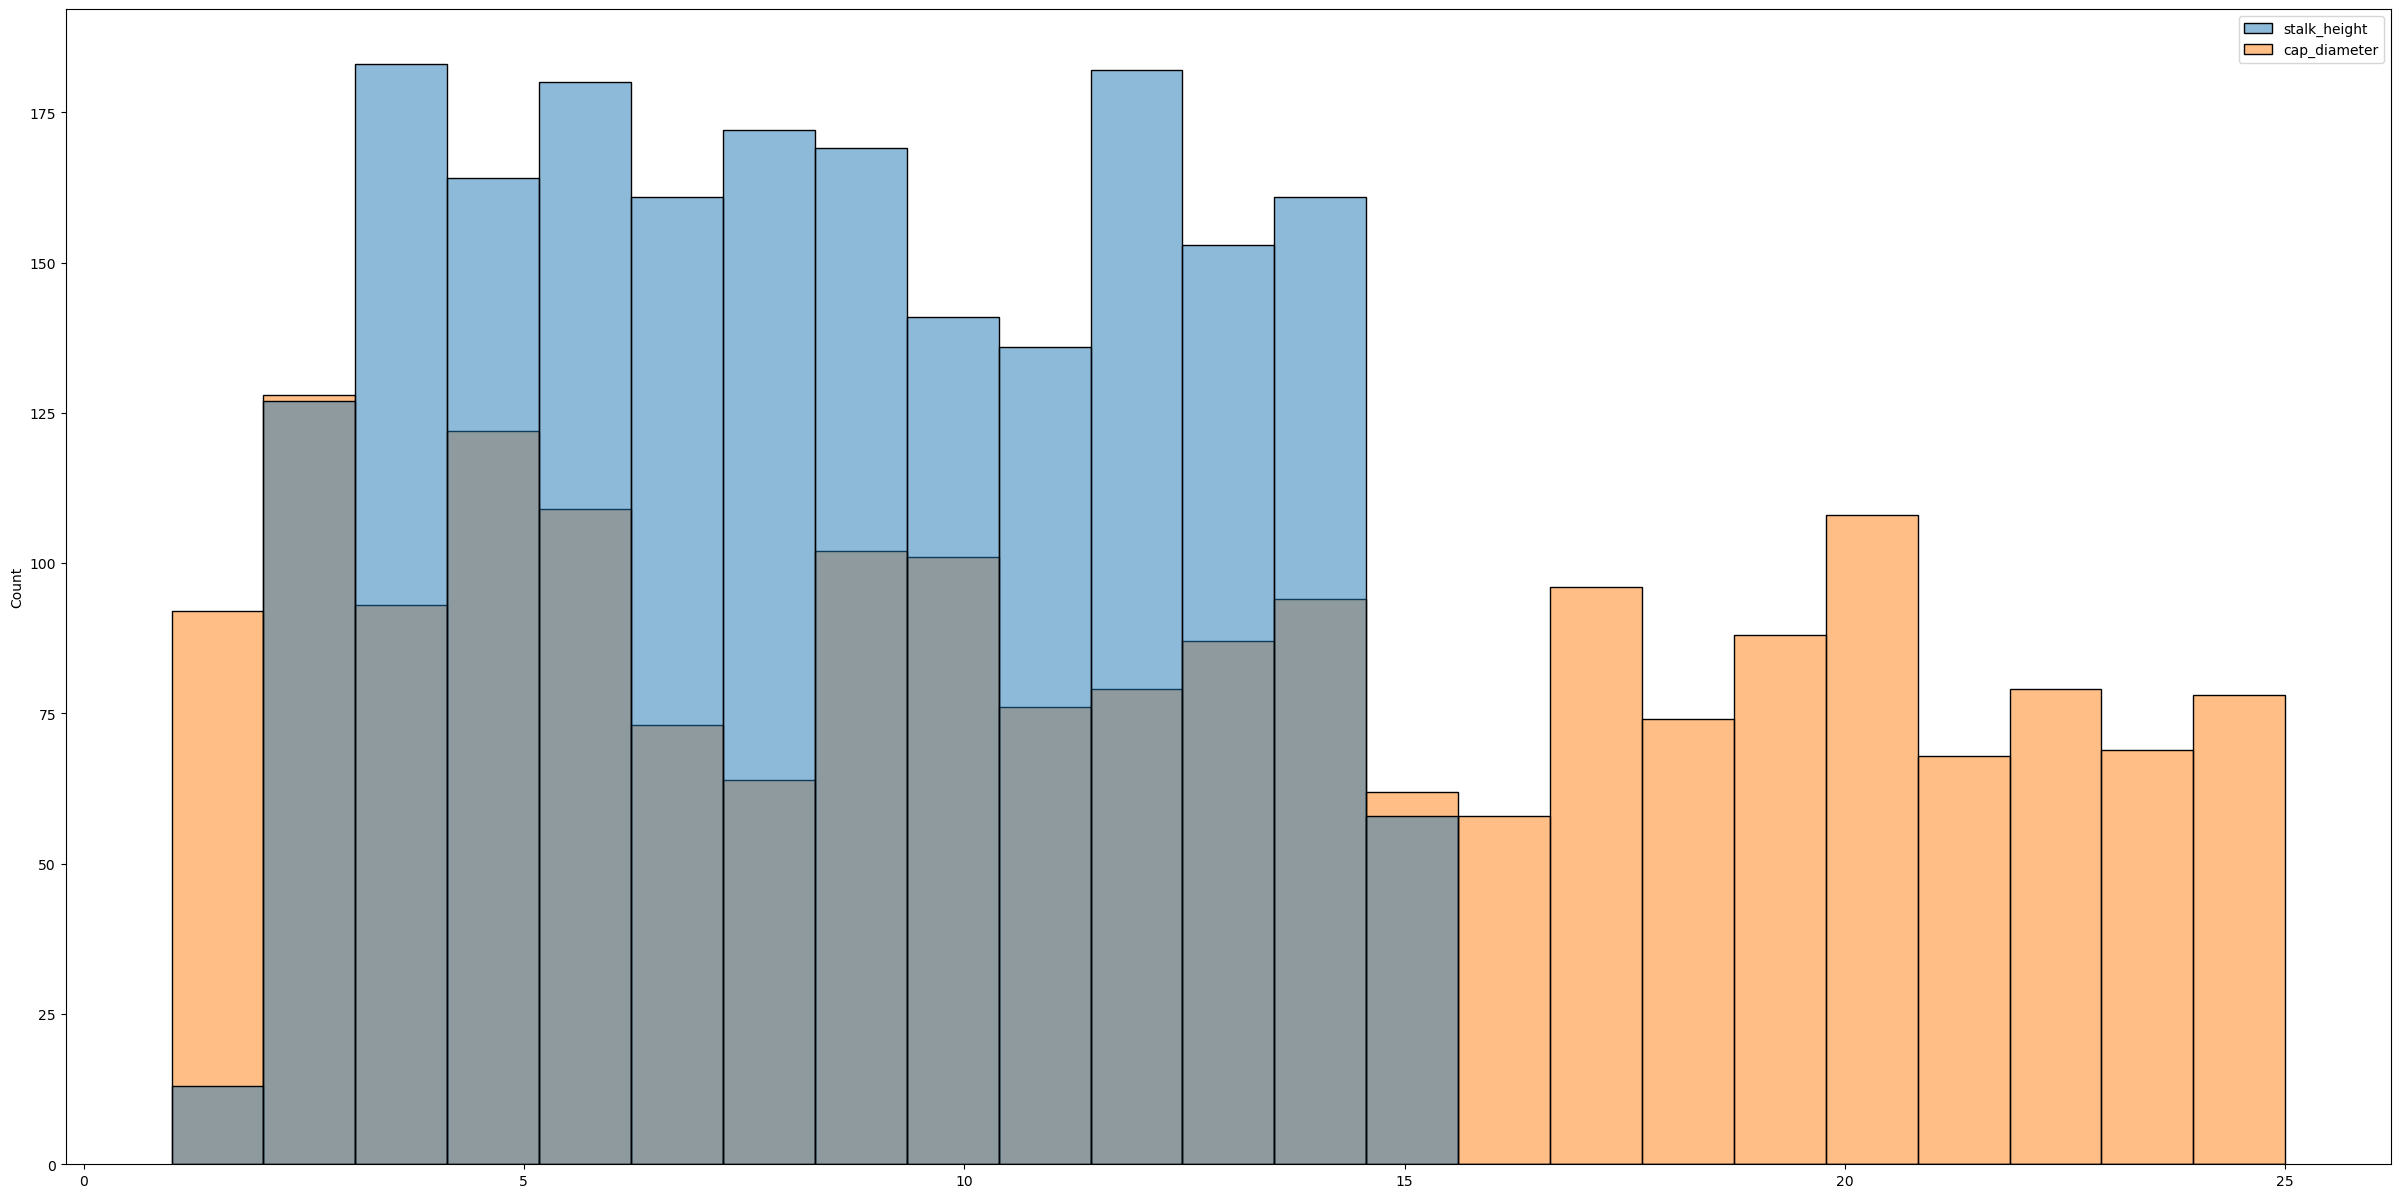

In [29]:
plt.figure(figsize=(30,15))
histplot = sns.histplot(data1)
histplot

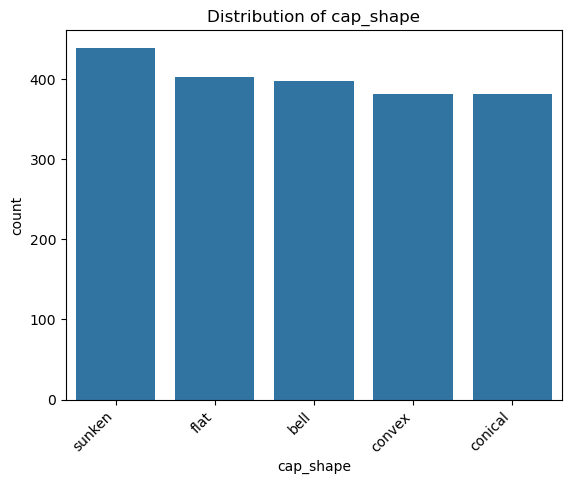

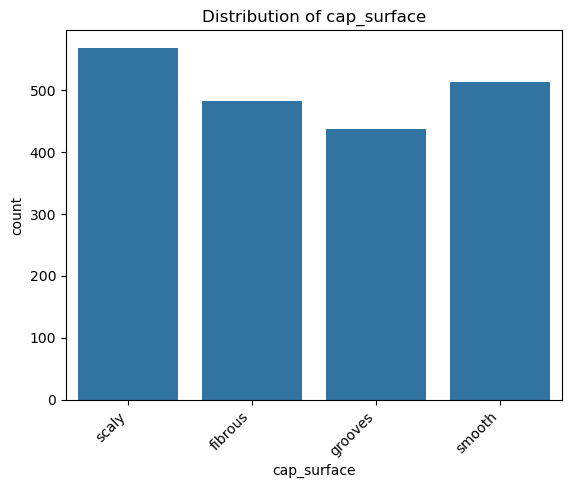

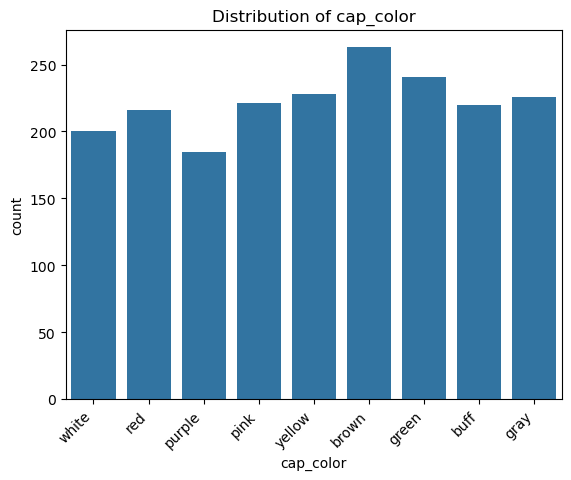

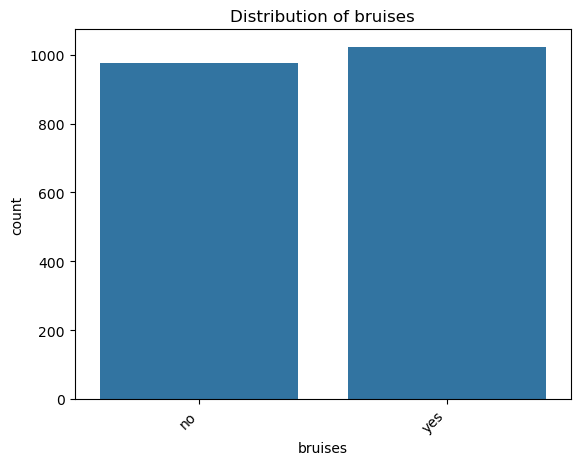

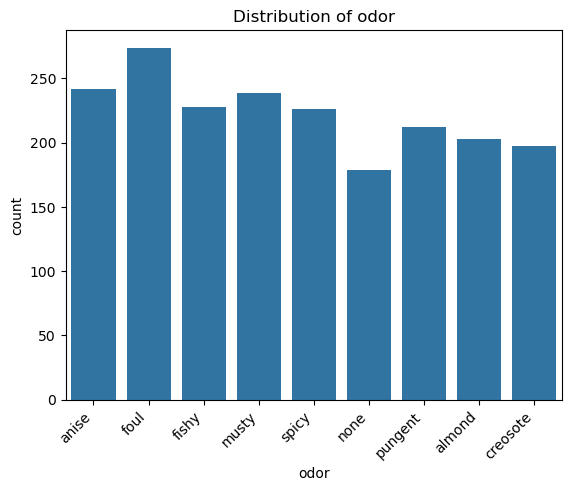

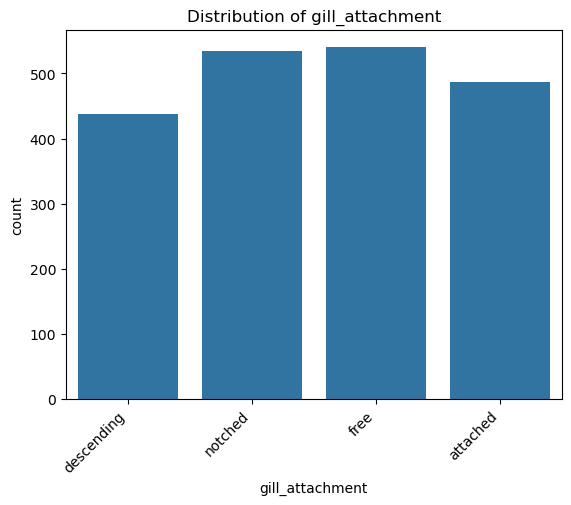

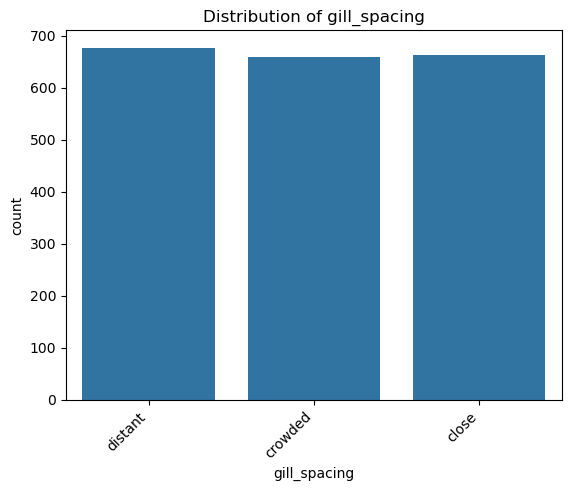

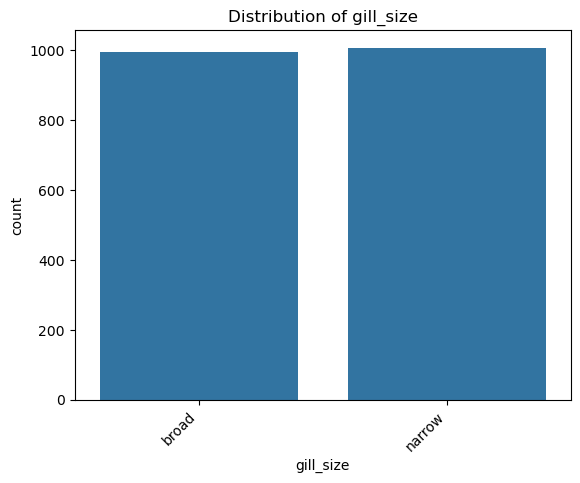

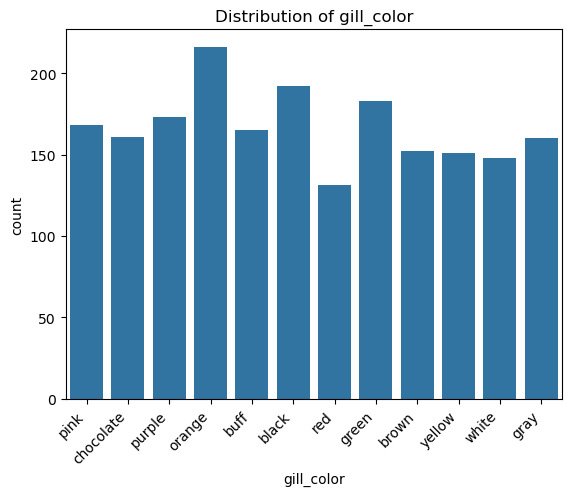

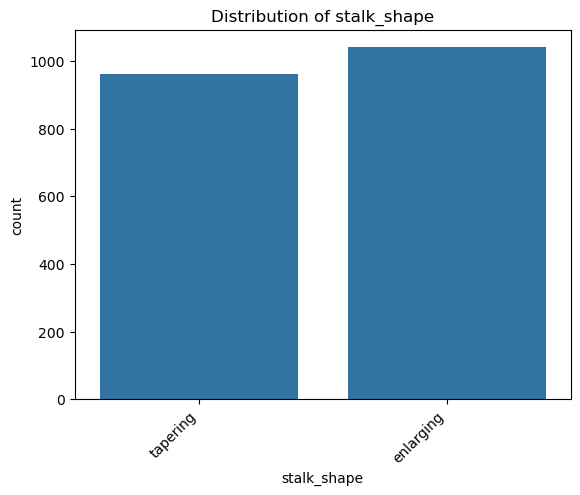

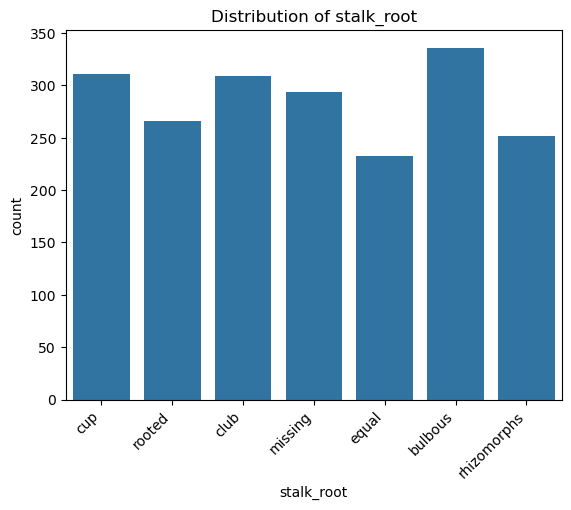

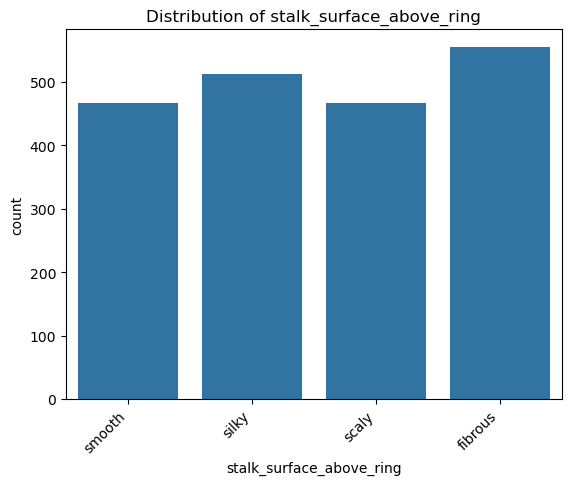

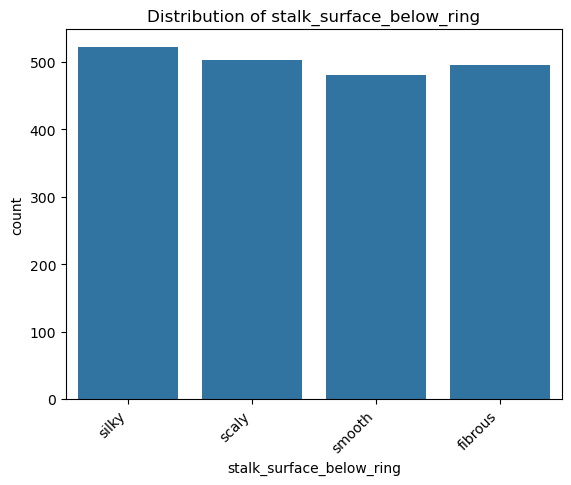

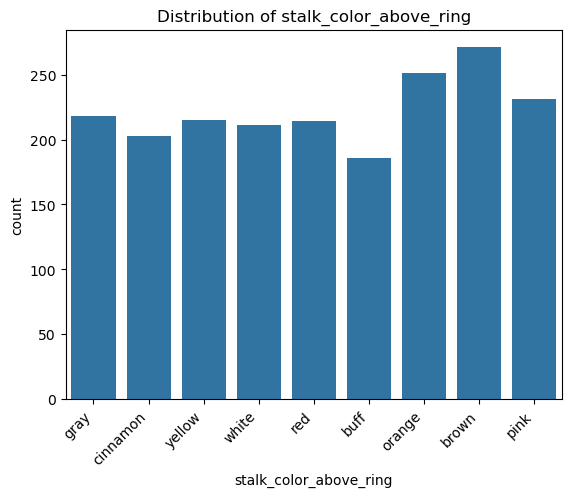

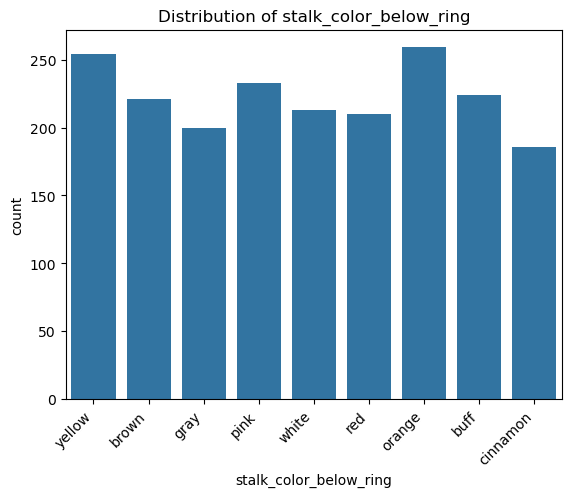

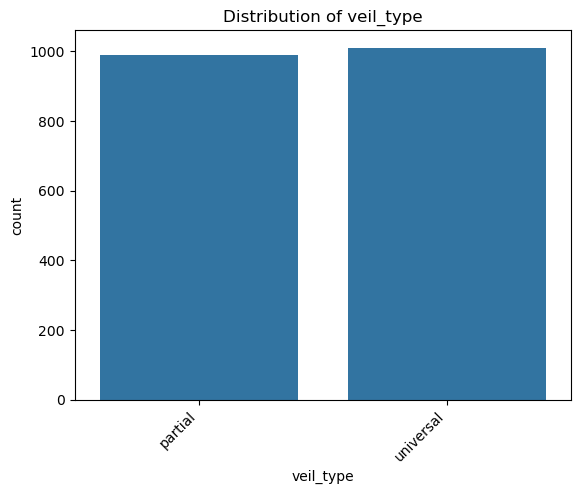

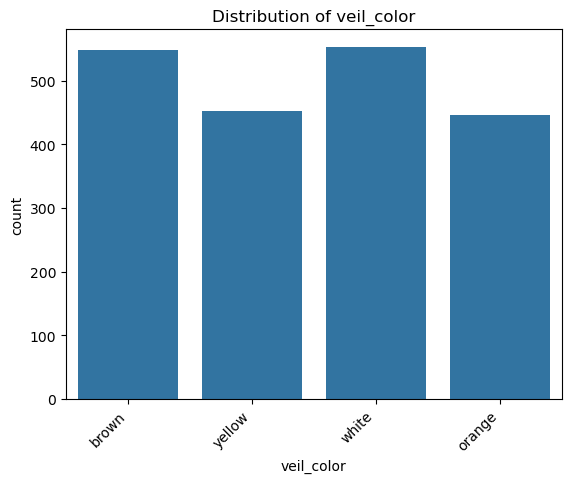

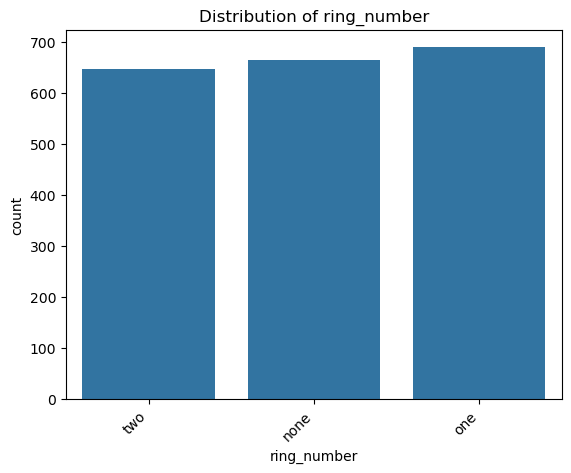

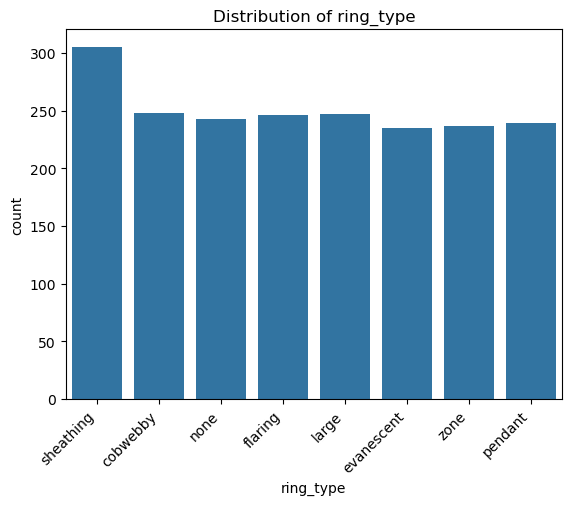

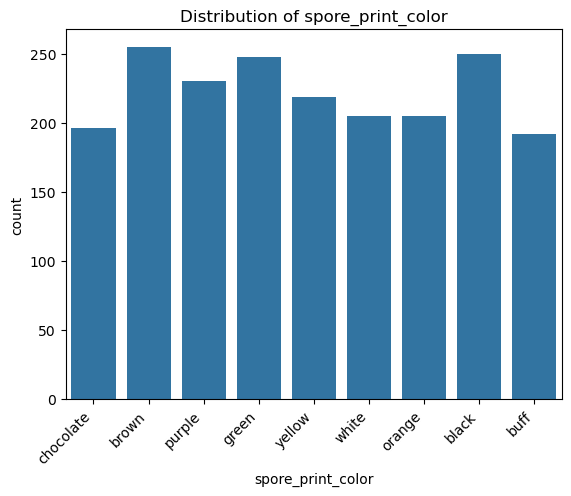

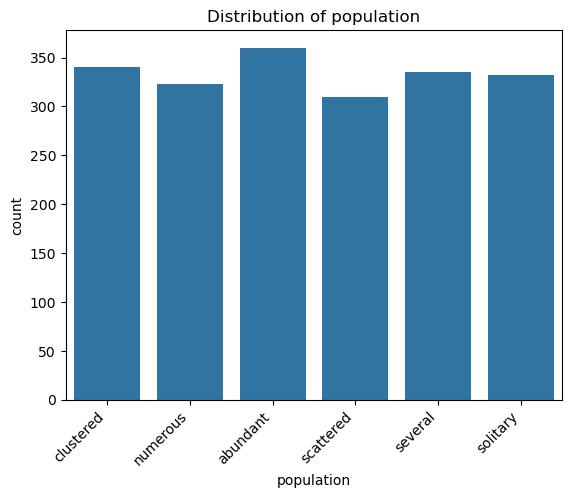

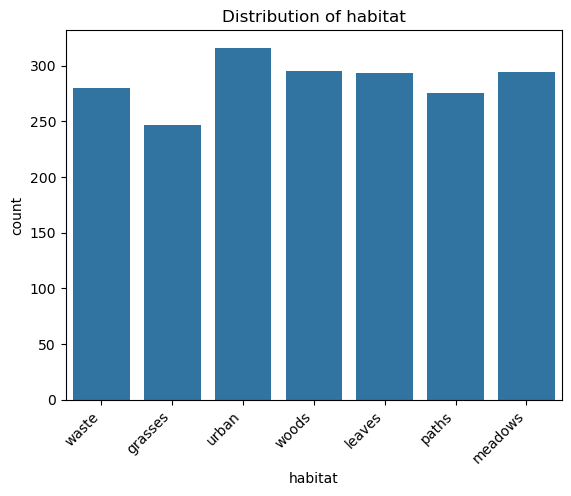

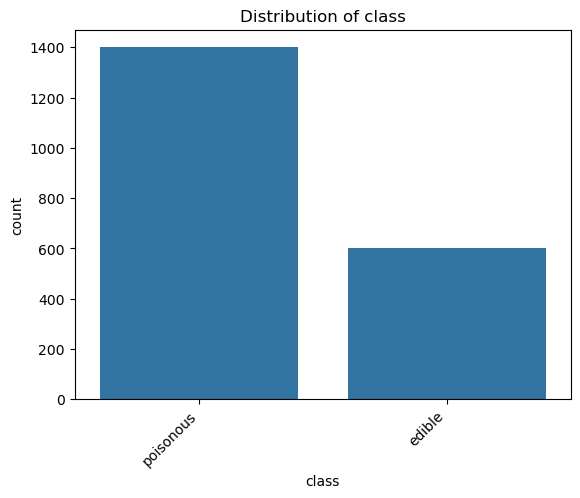

In [32]:
# Histograms for categorical features
for col in dataset.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(x=col, data=data1)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for readability
    plt.show()

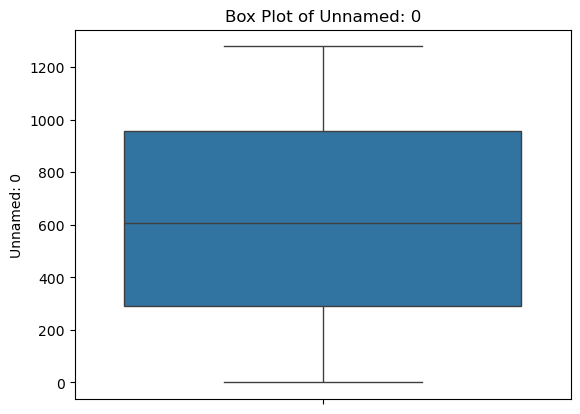

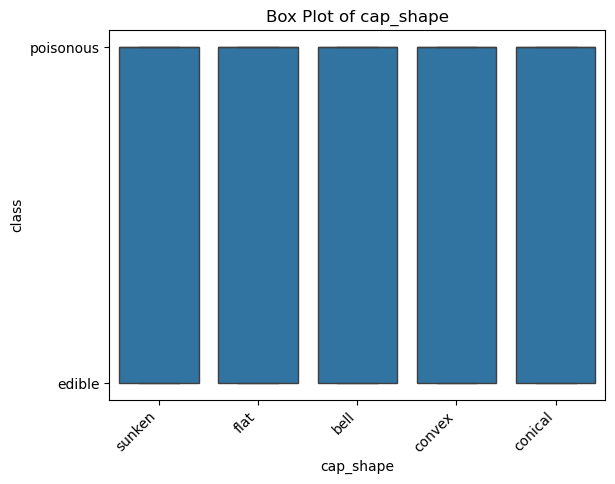

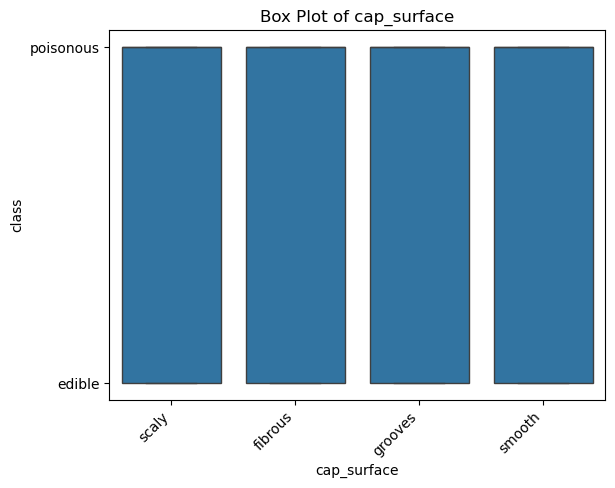

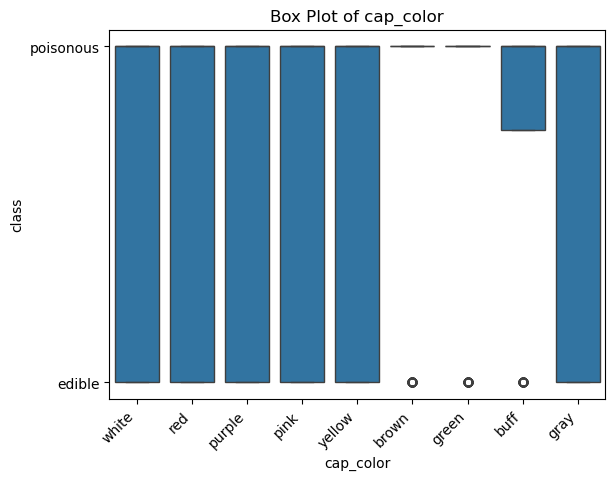

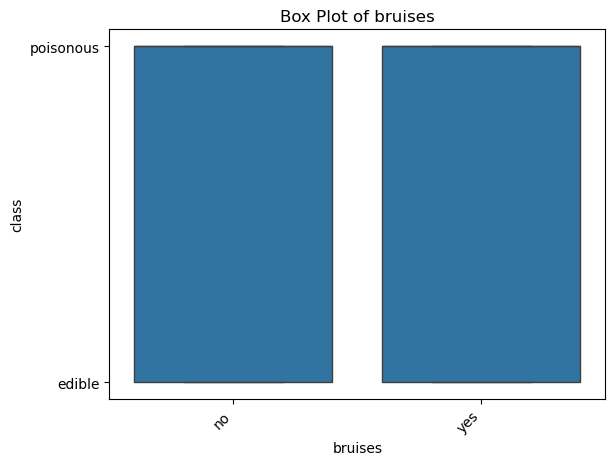

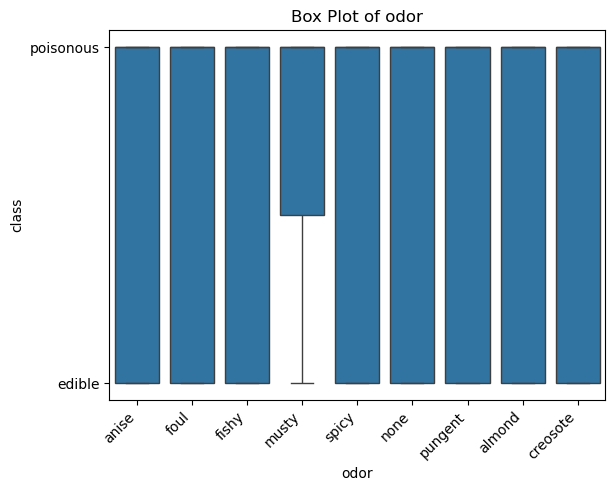

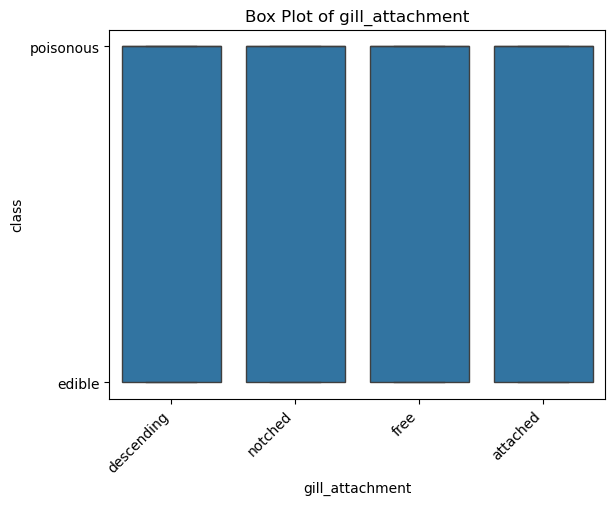

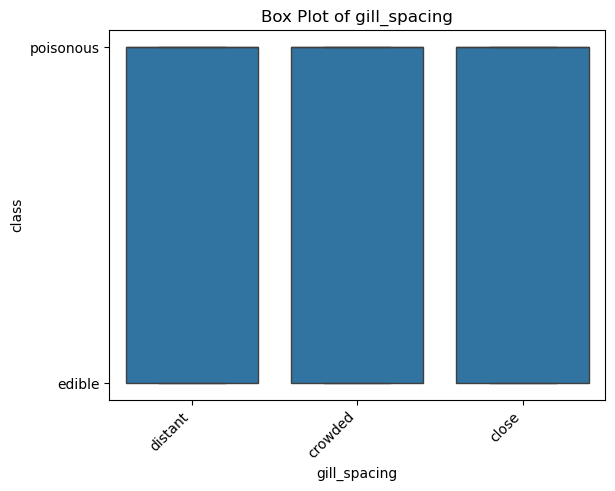

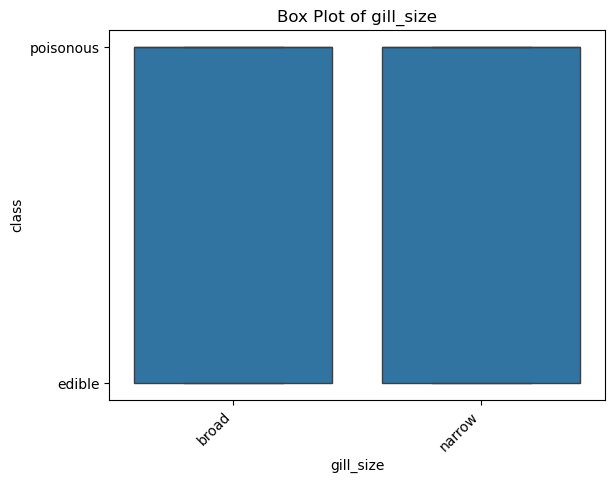

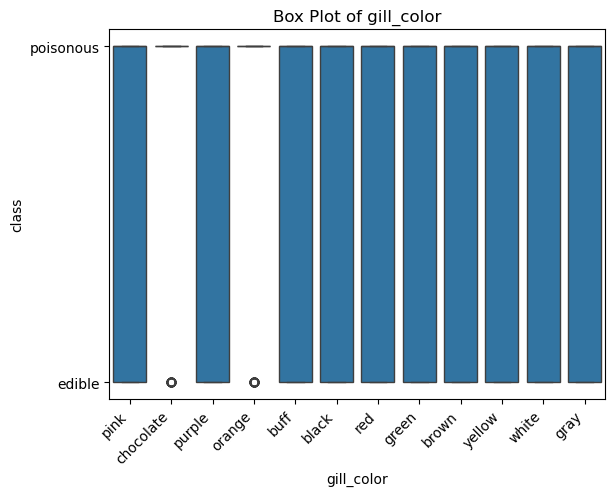

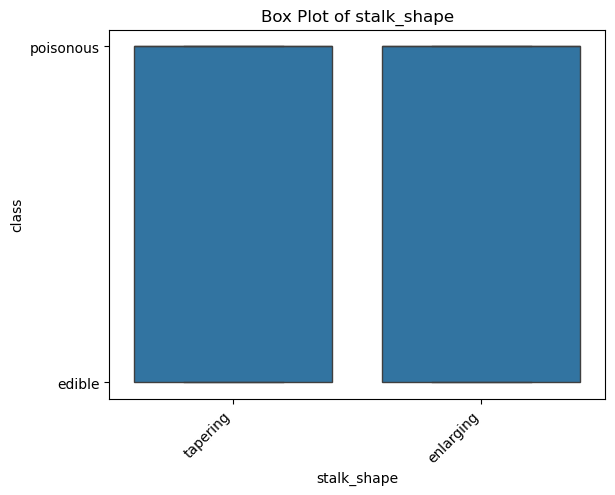

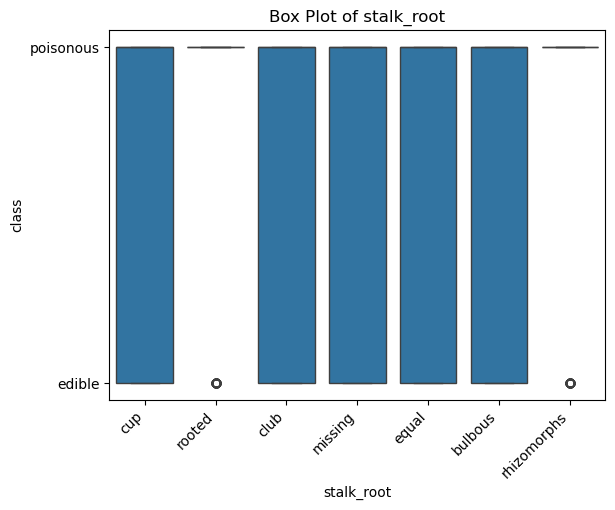

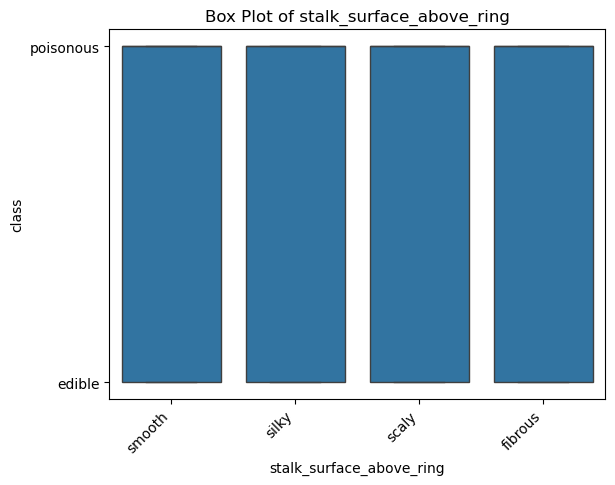

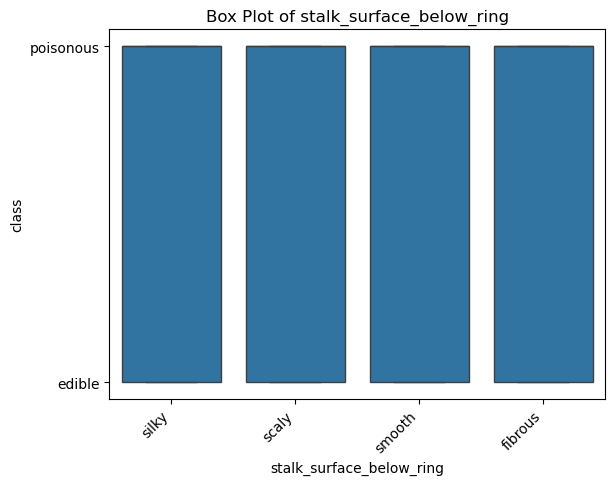

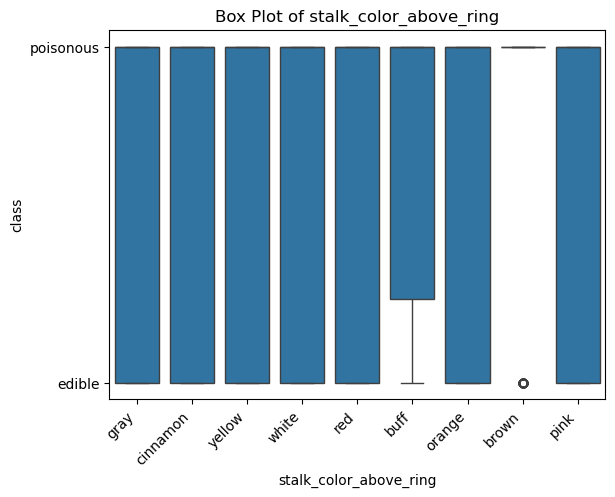

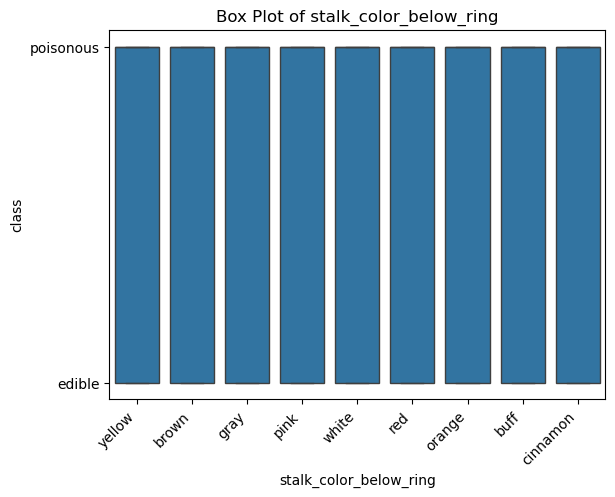

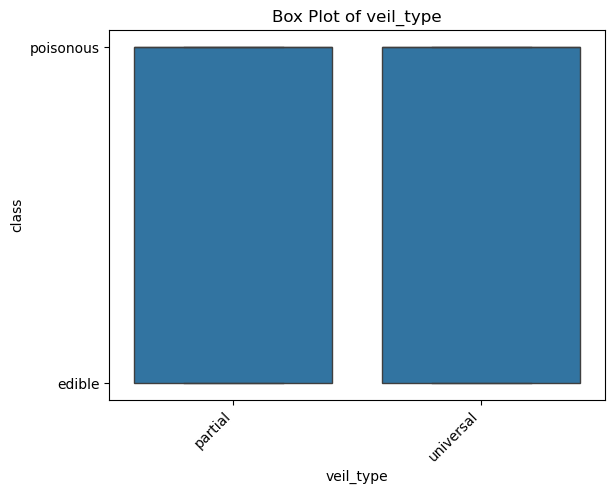

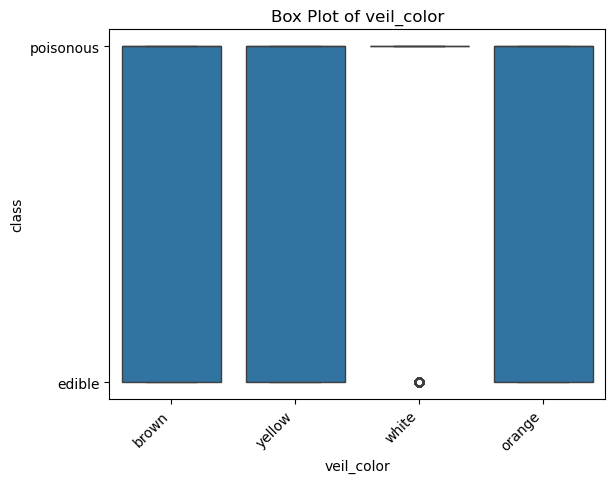

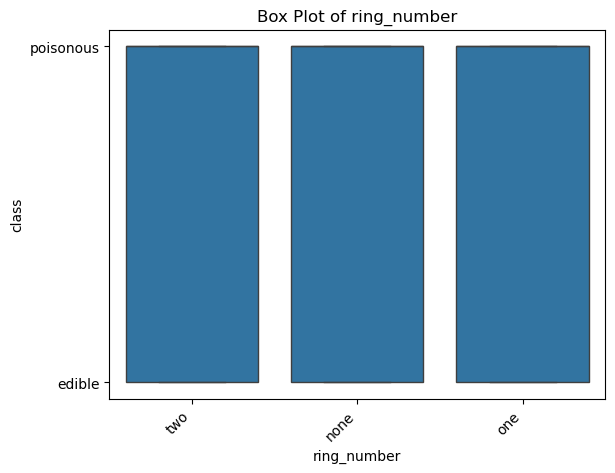

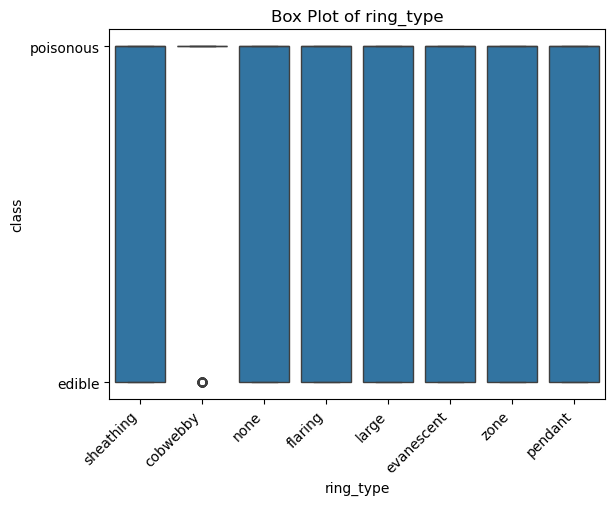

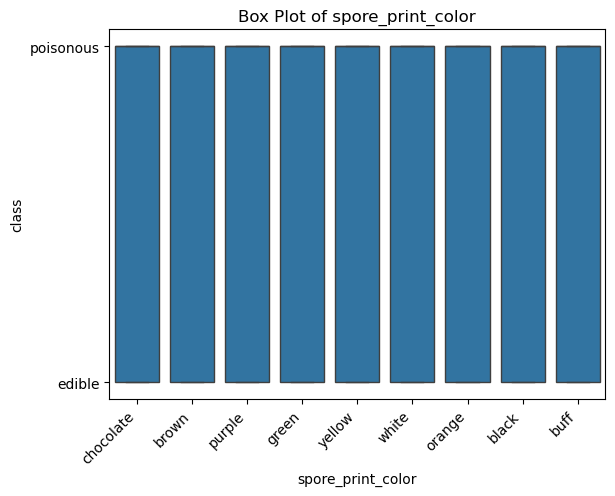

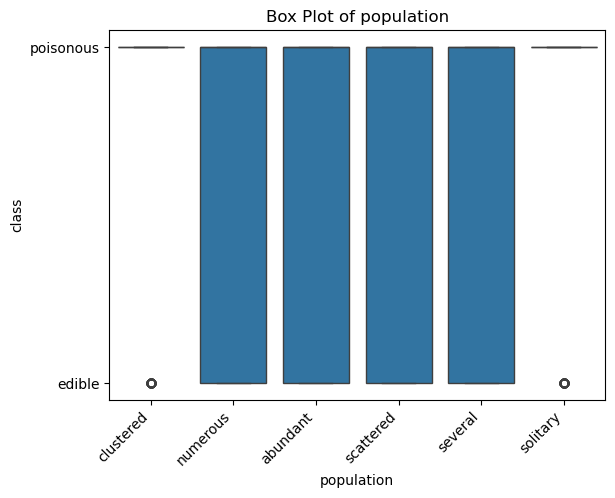

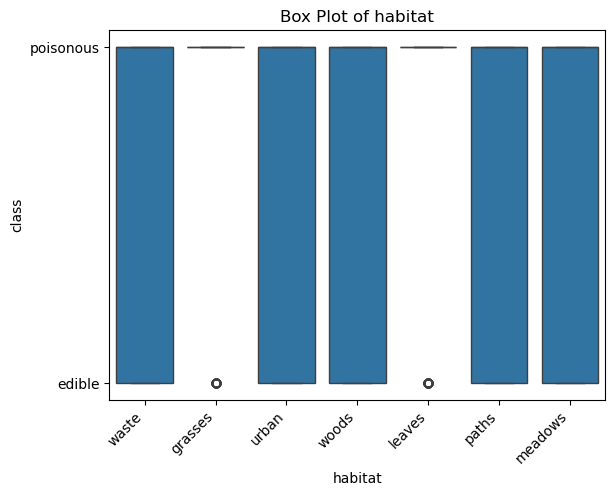

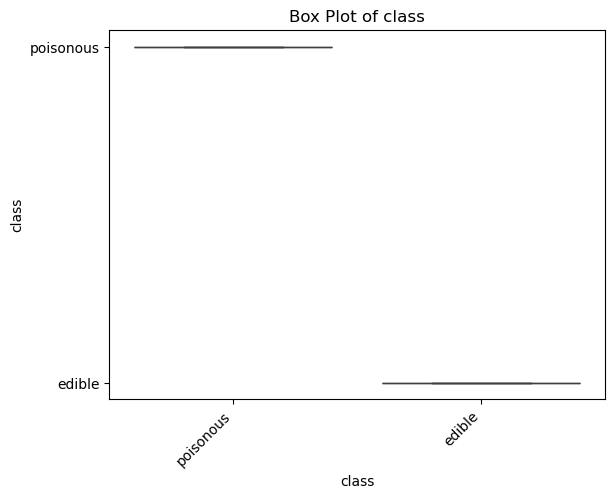

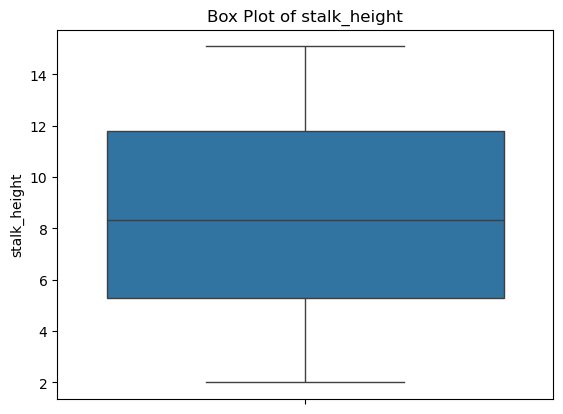

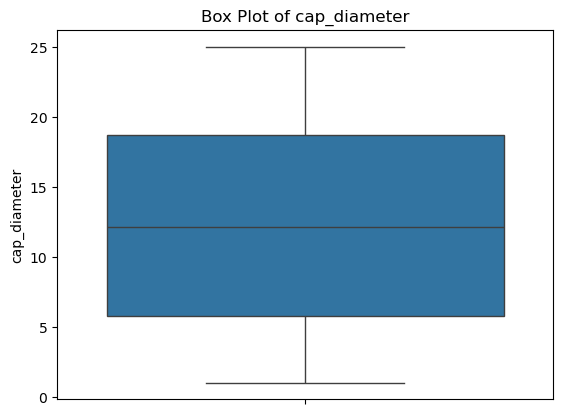

In [14]:
# box plot 
for col in dataset.columns:
    plt.figure()
    if dataset[col].dtype == 'object':
        sns.boxplot(x=col, y='class', data=dataset)  
        plt.xticks(rotation=45, ha='right')
    else:
        sns.boxplot(y=col, data=dataset) 
    plt.title(f'Box Plot of {col}')
    plt.show()

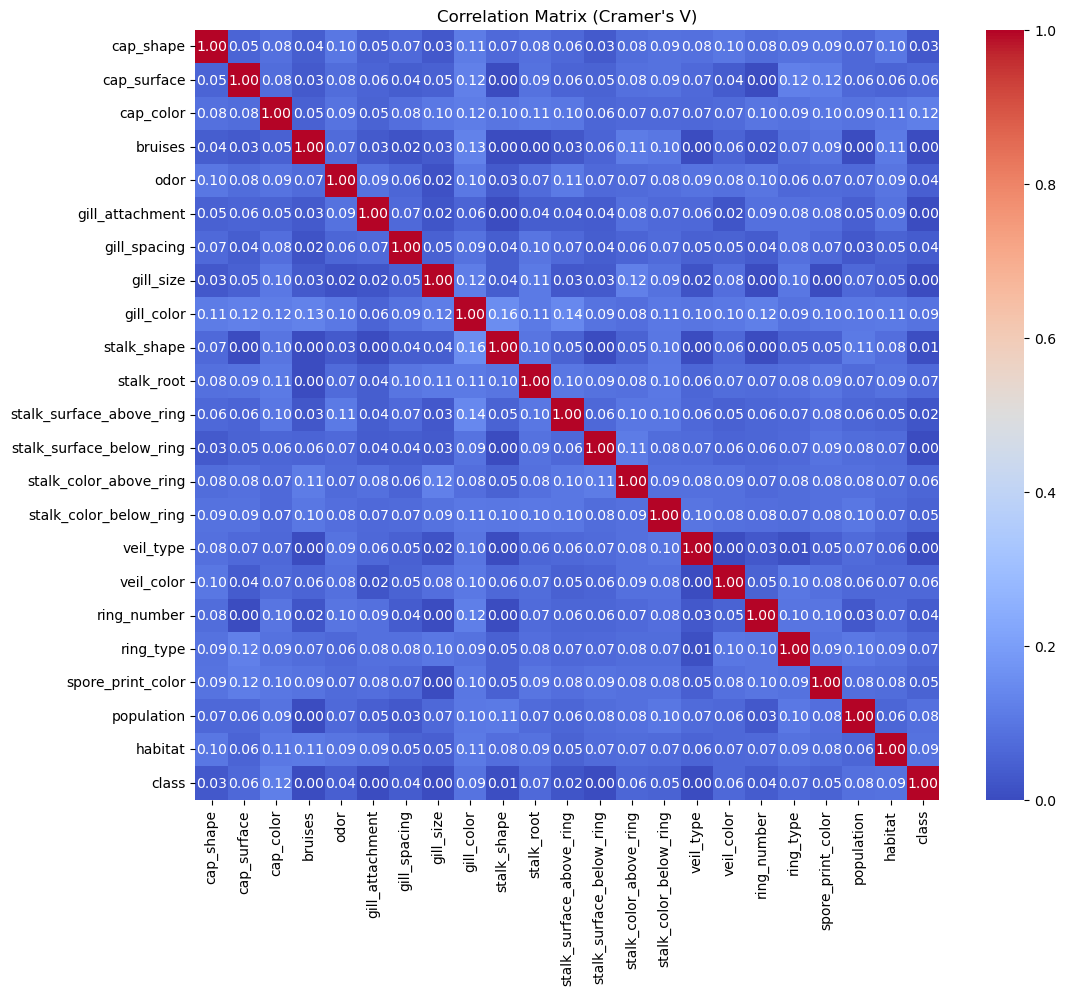

In [33]:
# Heat Map:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))
categorical_cols = dataset.select_dtypes(include=['object']).columns
corr_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)
for col1 in categorical_cols:
    for col2 in categorical_cols:
        corr_matrix.loc[col1, col2] = cramers_v(data1[col1], data1[col2])
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Cramer\'s V)')
plt.show()

# Task 3: Data Preprocessing

In [35]:
freatures = data1.drop(columns='class')
freatures

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter
0,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,...,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,14.276173,5.054983
1,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,...,brown,universal,brown,two,sheathing,brown,numerous,waste,3.952715,19.068319
2,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,...,gray,universal,yellow,two,sheathing,purple,abundant,waste,9.054265,7.205884
3,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,...,pink,partial,yellow,two,cobwebby,green,clustered,grasses,5.226499,20.932692
4,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,...,white,universal,white,none,none,yellow,clustered,urban,14.037532,12.545245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sunken,scaly,brown,yes,foul,attached,crowded,narrow,chocolate,tapering,...,orange,partial,orange,one,flaring,purple,abundant,leaves,5.877891,17.464145
1996,sunken,scaly,purple,yes,musty,attached,distant,narrow,red,tapering,...,orange,partial,white,one,zone,yellow,numerous,waste,6.500840,13.501957
1997,convex,grooves,green,yes,fishy,notched,close,narrow,pink,tapering,...,red,partial,brown,two,evanescent,yellow,abundant,woods,13.558064,11.270020
1998,bell,smooth,white,no,pungent,free,close,narrow,orange,enlarging,...,pink,universal,yellow,one,cobwebby,brown,solitary,woods,11.092703,8.423199


In [36]:
target = data1[['class']]
target

,class
0,poisonous
1,edible
2,poisonous
3,poisonous
4,poisonous
...,...
1995,poisonous
1996,poisonous
1997,poisonous
1998,poisonous


## To find categrical and numerical columns from the data.

In [37]:
cat_col = [i for i in freatures.columns if freatures[i].dtype=='O']
cat_col

['cap_shape',
 'cap_surface',
 'cap_color',
 'bruises',
 'odor',
 'gill_attachment',
 'gill_spacing',
 'gill_size',
 'gill_color',
 'stalk_shape',
 'stalk_root',
 'stalk_surface_above_ring',
 'stalk_surface_below_ring',
 'stalk_color_above_ring',
 'stalk_color_below_ring',
 'veil_type',
 'veil_color',
 'ring_number',
 'ring_type',
 'spore_print_color',
 'population',
 'habitat']

In [38]:
Num_col = [i for i in freatures.columns if freatures[i].dtype!='O']
Num_col 

['stalk_height', 'cap_diameter']

# Task 2: Data Preprocessing

## convertion of catagrical data.

In [40]:
ord_end = make_pipeline(OrdinalEncoder())

In [41]:
trans = ColumnTransformer([('ordinal',ord_end,cat_col)])

In [42]:
cal_fre = pd.DataFrame(trans.fit_transform(freatures))
cal_fre

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,4.0,2.0,7.0,0.0,1.0,1.0,2.0,0.0,7.0,1.0,...,2.0,3.0,8.0,0.0,0.0,2.0,6.0,3.0,1.0,5.0
1,4.0,0.0,6.0,0.0,1.0,3.0,1.0,1.0,3.0,0.0,...,2.0,2.0,0.0,1.0,0.0,2.0,6.0,1.0,2.0,5.0
2,3.0,1.0,5.0,1.0,4.0,1.0,1.0,0.0,8.0,1.0,...,2.0,8.0,3.0,1.0,3.0,2.0,6.0,6.0,0.0,5.0
3,0.0,2.0,4.0,1.0,3.0,3.0,0.0,0.0,6.0,0.0,...,1.0,8.0,5.0,0.0,3.0,2.0,0.0,4.0,1.0,0.0
4,3.0,3.0,8.0,1.0,5.0,2.0,1.0,1.0,6.0,0.0,...,1.0,3.0,7.0,1.0,2.0,0.0,4.0,8.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4.0,2.0,0.0,1.0,4.0,0.0,1.0,1.0,3.0,1.0,...,2.0,5.0,4.0,0.0,1.0,1.0,2.0,6.0,0.0,1.0
1996,4.0,2.0,5.0,1.0,5.0,0.0,2.0,1.0,9.0,1.0,...,0.0,5.0,4.0,0.0,2.0,1.0,7.0,8.0,2.0,5.0
1997,2.0,1.0,3.0,1.0,3.0,3.0,0.0,1.0,7.0,1.0,...,2.0,0.0,6.0,0.0,0.0,2.0,1.0,8.0,0.0,6.0
1998,0.0,3.0,7.0,0.0,7.0,2.0,0.0,1.0,6.0,0.0,...,0.0,3.0,5.0,1.0,3.0,1.0,0.0,1.0,5.0,6.0


## Convertion of numarical data.

In [43]:
Num_fre = pd.DataFrame(freatures[Num_col])
Num_fre

,stalk_height,cap_diameter
0,14.276173,5.054983
1,3.952715,19.068319
2,9.054265,7.205884
3,5.226499,20.932692
4,14.037532,12.545245
...,...,...
1995,5.877891,17.464145
1996,6.500840,13.501957
1997,13.558064,11.270020
1998,11.092703,8.423199


In [44]:
std = StandardScaler()

In [45]:
Num1_fre = pd.DataFrame(std.fit_transform(Num_fre))
Num1_fre

,0,1
0,1.576459,-1.030123
1,-1.216463,0.958407
2,0.163717,-0.724904
3,-0.871852,1.222967
4,1.511897,0.032765
...,...,...
1995,-0.695623,0.730771
1996,-0.527090,0.168525
1997,1.382181,-0.148193
1998,0.715199,-0.552164


## Combine of both the data.

In [46]:
freatures1 = pd.concat([cal_fre,Num1_fre],axis=1,ignore_index=True)
old_name = range(0,22)
new_name = cat_col
old1_name = range(22,24)
new1_name = Num_col
freatures2 = freatures1.rename(columns=dict(zip(old_name,new_name)))
freatures3 = freatures2.rename(columns=dict(zip(old1_name,new1_name)))
freatures3

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,...,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,stalk_height,cap_diameter
0,4.0,2.0,7.0,0.0,1.0,1.0,2.0,0.0,7.0,1.0,...,8.0,0.0,0.0,2.0,6.0,3.0,1.0,5.0,1.576459,-1.030123
1,4.0,0.0,6.0,0.0,1.0,3.0,1.0,1.0,3.0,0.0,...,0.0,1.0,0.0,2.0,6.0,1.0,2.0,5.0,-1.216463,0.958407
2,3.0,1.0,5.0,1.0,4.0,1.0,1.0,0.0,8.0,1.0,...,3.0,1.0,3.0,2.0,6.0,6.0,0.0,5.0,0.163717,-0.724904
3,0.0,2.0,4.0,1.0,3.0,3.0,0.0,0.0,6.0,0.0,...,5.0,0.0,3.0,2.0,0.0,4.0,1.0,0.0,-0.871852,1.222967
4,3.0,3.0,8.0,1.0,5.0,2.0,1.0,1.0,6.0,0.0,...,7.0,1.0,2.0,0.0,4.0,8.0,1.0,4.0,1.511897,0.032765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4.0,2.0,0.0,1.0,4.0,0.0,1.0,1.0,3.0,1.0,...,4.0,0.0,1.0,1.0,2.0,6.0,0.0,1.0,-0.695623,0.730771
1996,4.0,2.0,5.0,1.0,5.0,0.0,2.0,1.0,9.0,1.0,...,4.0,0.0,2.0,1.0,7.0,8.0,2.0,5.0,-0.527090,0.168525
1997,2.0,1.0,3.0,1.0,3.0,3.0,0.0,1.0,7.0,1.0,...,6.0,0.0,0.0,2.0,1.0,8.0,0.0,6.0,1.382181,-0.148193
1998,0.0,3.0,7.0,0.0,7.0,2.0,0.0,1.0,6.0,0.0,...,5.0,1.0,3.0,1.0,0.0,1.0,5.0,6.0,0.715199,-0.552164


## Spliting of the dataset into training and testing sets.

In [47]:
X_train,X_test,Y_train,Y_test = train_test_split(freatures3,target,train_size=0.75,random_state=100)

# Task 3: Data Visualization

## To Visualize in a scatter plot.

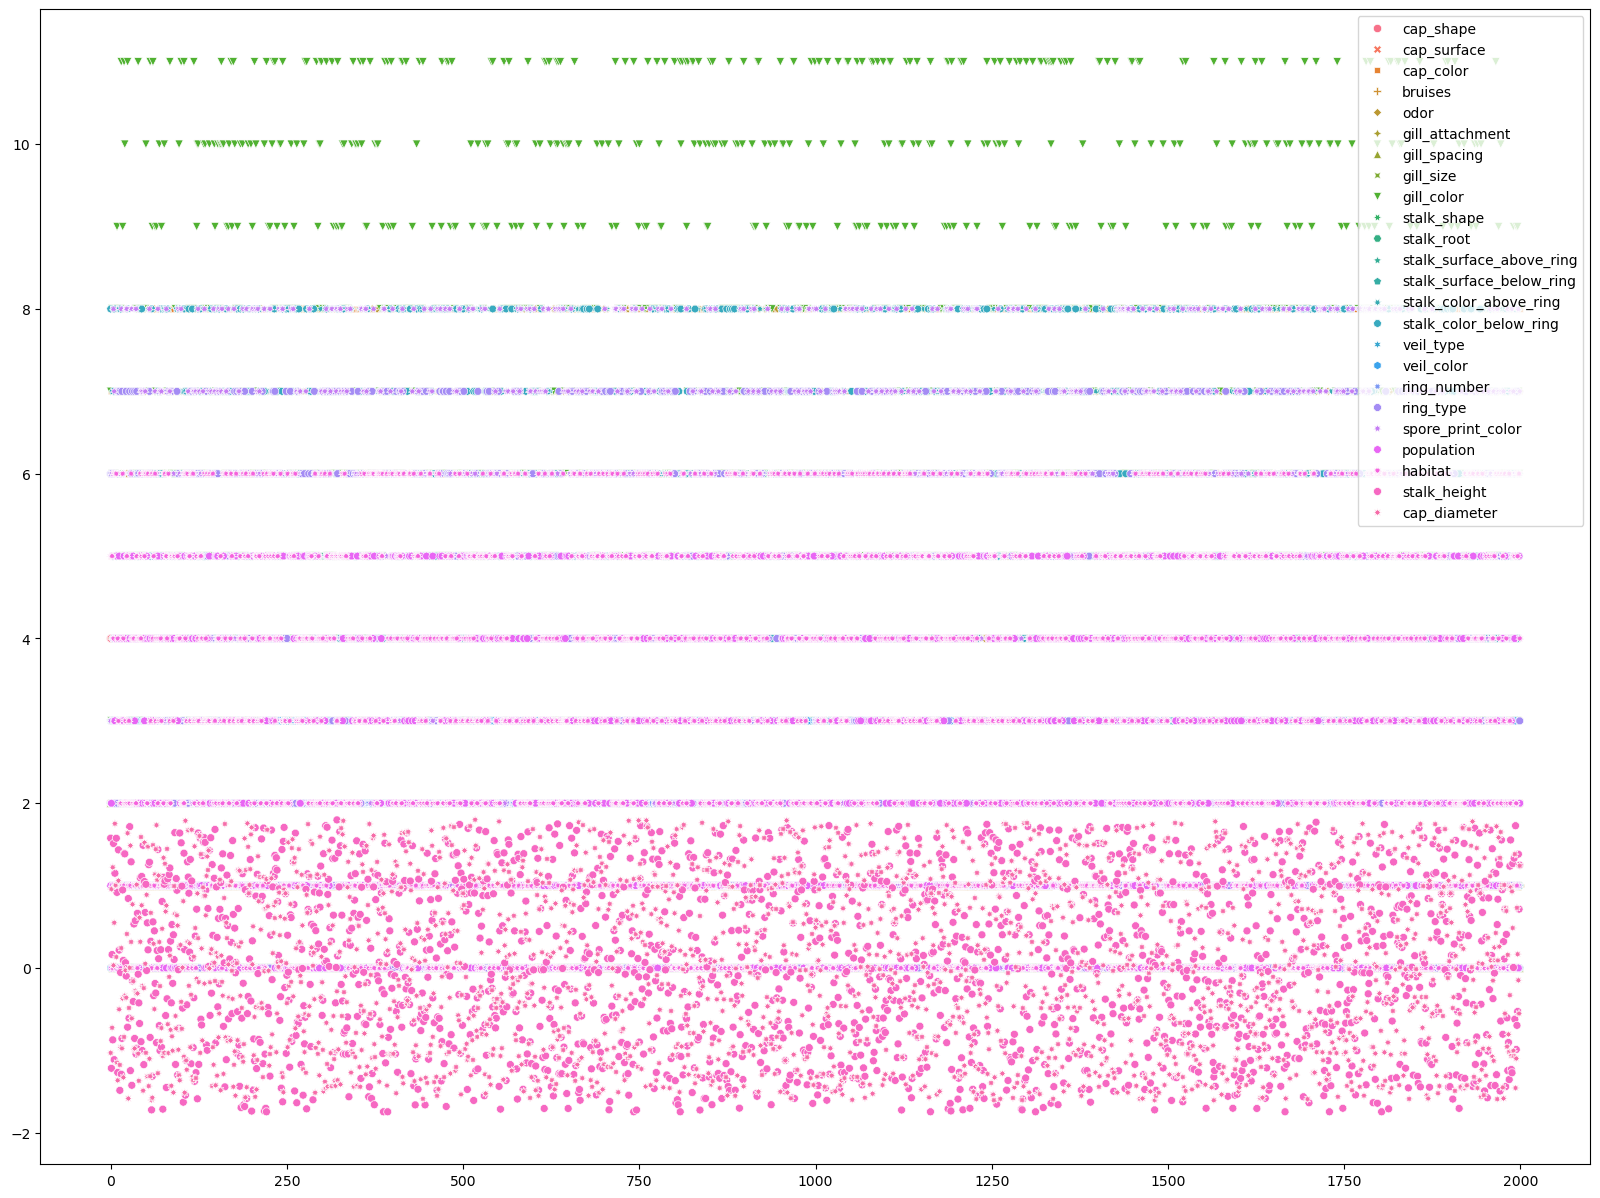

In [54]:
fig = plt.figure(figsize=(20, 15))
scatter = sns.scatterplot(freatures3)
plt.show()

# Task 4: SVM Implementation

In [55]:
svm = SVC(C=1.0, kernel='poly',degree=6,gamma='scale')

In [56]:
svm.fit(X_train,Y_train)

SVC(degree=6, kernel='poly')

In [57]:
Y_pred = svm.predict(X_test)

In [58]:
accuracy_score(Y_test,Y_pred)

0.866

In [59]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

      edible       0.90      0.68      0.78       171
   poisonous       0.85      0.96      0.90       329

    accuracy                           0.87       500
   macro avg       0.88      0.82      0.84       500
weighted avg       0.87      0.87      0.86       500



## --> The above output tells about the precision,recall,f1-score and accuracy.

# Task 5: Visualization of SVM Results

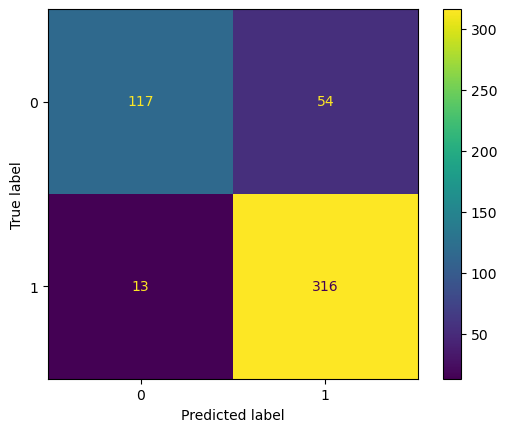

In [61]:
cm = confusion_matrix(Y_test,Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Task 6: Parameter Tuning and Optimization

## Comparison and Analysis

## Experiment with different SVM hyperparameters linear.

In [63]:
svm = SVC(C=1.0, kernel='linear',degree=6,gamma='scale')

In [64]:
svm.fit(X_train,Y_train)

SVC(degree=6, kernel='linear')

In [65]:
Y_pred = svm.predict(X_test)

In [66]:
accuracy_score(Y_test,Y_pred)

0.658

In [67]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

      edible       0.00      0.00      0.00       171
   poisonous       0.66      1.00      0.79       329

    accuracy                           0.66       500
   macro avg       0.33      0.50      0.40       500
weighted avg       0.43      0.66      0.52       500



## Experiment with different SVM hyperparameters sigmoid.

In [68]:
svm = SVC(C=1.0, kernel='sigmoid',degree=6,gamma='scale')

In [69]:
svm.fit(X_train,Y_train)

SVC(degree=6, kernel='sigmoid')

In [70]:
Y_pred = svm.predict(X_test)

In [71]:
accuracy_score(Y_test,Y_pred)

0.586

## Experiment with different SVM hyperparameters poly.

In [73]:
svm = SVC(C=1.0, kernel='linear',degree=4,gamma='scale')

In [74]:
svm.fit(X_train,Y_train)

SVC(degree=4, kernel='linear')

In [75]:
Y_pred = svm.predict(X_test)

In [76]:
accuracy_score(Y_test,Y_pred)

0.658

# Task 7: Comparison and Analysis

## --> While observeing all kernels 'Poly' is giving best accuracy.